In [1]:
import numpy as np 
import matplotlib.pyplot as plt

from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import LeakyReLU # relu varyasyonu. ölü nöronlar sorununu ortadan kaldırır. girdi x ise çıktı x olur. girdi -x ise çıktı -a olur. a çok küçük bir sayı.
from keras.layers import Dense, Reshape, Flatten, Conv2D, Conv2DTranspose, BatchNormalization
from keras.optimizers import Adam

from tqdm import tqdm #for döngüsüne ilerleme sayıcı ekleme

import warnings
warnings.filterwarnings("ignore")

2025-07-26 15:12:45.650531: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
#mnist veri setini yükleme
(x_train, _), (_, _ ) = mnist.load_data() # sadece train veri setini yükleme

#normalizasyon 
x_train = x_train / 255.0

#boyutların ayarlanması (28x28) -> (28, 28, 1)
x_train = np.expand_dims(x_train, axis = -1)

In [3]:
#create discriminator and generator
#gan parametreleri
z_dim = 100 #gürültü vektörünün boyutu

#discriminator modelini tanımla
def build_discriminator():
    model = Sequential()
    #Conv2D: 64 filtre, 3x3 çekirdek (kernel), stride = 2, padding = same, activation = LeakyRelu
    model.add(Conv2D(64, kernel_size=3, strides=2, padding="same", input_shape=(28,28,1)))
    model.add(LeakyReLU(alpha=0.2))
    #Conv2D: 128 filtre, 3x3 çekirdek (kernel), stride = 2, padding = same, activation = LeakyRelu
    model.add(Conv2D(64, kernel_size=3, strides=2, padding="same"))
    model.add(LeakyReLU(alpha=0.2))
    #flatten -> output layer
    model.add(Flatten()) # görüntüyü tek boyutlu vektöre dönüştürür
    model.add(Dense(1, activation="sigmoid"))
    #compile
    model.compile(loss = "binary_crossentropy", optimizer=Adam(0.0002, 0.5), metrics=["accuracy"])
    return model

In [4]:
#generator modelini tanımlama 
def build_generator():
    model = Sequential()
    model.add(Dense(7*7*128, input_dim = z_dim)) # gürültü vektörlerinden yüksek boyutlu uzaya dönüşüm
    model.add(LeakyReLU(alpha=0.2))
    model.add(Reshape((7,7,128))) #çıkışı (7x7x128) olacak şekilde ayarlıyoruz
    model.add(BatchNormalization())
    model.add(Conv2DTranspose(64, kernel_size=3, strides=2, padding="same"))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization())
    model.add(Conv2DTranspose(1, kernel_size=3,strides=2, padding="same", activation="tanh"))
    return model

In [5]:
#create GAN model
def build_gan(generator, discriminator):
    discriminator.trainable = False  #discriminator eğitilemez
    
    model = Sequential()
    model.add(generator) # gan yapısına ilk olarak generator ekliyoruz
    model.add(discriminator) # gan yapısına discriminator ekleme
    model.compile(loss="binary_crossentropy", optimizer=Adam())
    return model

In [6]:
discriminator = build_discriminator() #discriminator modeli oluşturma
generator = build_generator() #generator modeli oluşturma 
gan = build_gan(generator, discriminator) #gan modeli oluşturma

print(gan.summary())

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_1 (Sequential)   (None, 28, 28, 1)         708609    
                                                                 
 sequential (Sequential)     (None, 1)                 40705     
                                                                 
Total params: 749,314
Trainable params: 708,225
Non-trainable params: 41,089
_________________________________________________________________
None


2025-07-26 15:12:48.783501: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [7]:
#train GAN
epochs = 50000
batch_size = 64
half_batch = batch_size // 2

#eğitim döngüsü 
for epoch in tqdm(range(epochs), desc = "Training Process"): # tqdm ile ilerleme çubuğu eklenir
    #gerçek veriler ile discriminator eğitimi
    idx = np.random.randint(0, x_train.shape[0], half_batch)#x_train içerisinden rastgele 32 adet veri seçme
    real_images = x_train[idx] #gerçek görüntüler
    real_labels = np.ones((half_batch, 1)) #gerçek etiketler 1
    
    #fake verilerin (generator'ın ürettiği) ile discriminator eğitimi
    noise = np.random.normal(0,1, (half_batch, z_dim)) #gürültü vektörleri
    fake_images = generator.predict(noise, verbose=0) #üretilen görüntüler
    fake_labels = np.zeros((half_batch, 1)) #sahte etiketler 0
    
    #update discriminator
    d_loss_real = discriminator.train_on_batch(real_images, real_labels) #gerçek verilerle kayıp hesaplama
    d_loss_fake = discriminator.train_on_batch(fake_images, fake_labels) #fake verilerle kayıp hesaplama
    d_loss = np.add(d_loss_real, d_loss_fake) * 0.5 # ortalama kayıp
    
    #train gan 
    noise = np.random.normal(0,1, (batch_size, z_dim))#gürültü vektörleri
    valid_y = np.ones((batch_size, 1)) #doğru etiketler
    g_loss = gan.train_on_batch(noise, valid_y) #gan'ın içinde bulunan generatör training
    
    if epoch % 1000 == 0:
        print(f"{epoch}/{epochs} D loss: {d_loss[0]}, G loss: {g_loss}")

Training Process:   0%|          | 3/50000 [00:01<4:45:26,  2.92it/s] 

0/50000 D loss: 0.6885783970355988, G loss: 0.6912821531295776


Training Process:   2%|▏         | 1003/50000 [01:32<1:15:00, 10.89it/s]

1000/50000 D loss: 0.4343837648630142, G loss: 1.3767796754837036


Training Process:   4%|▍         | 2003/50000 [03:02<1:12:19, 11.06it/s]

...

Training Process:  96%|█████████▌| 48003/50000 [1:01:46<02:30, 13.28it/s]

48000/50000 D loss: 0.013045568019151688, G loss: 7.243535995483398


Training Process:  98%|█████████▊| 49003/50000 [1:03:01<01:16, 13.03it/s]

49000/50000 D loss: 0.012431580864358693, G loss: 8.328289031982422


Training Process: 100%|██████████| 50000/50000 [1:04:16<00:00, 12.96it/s]


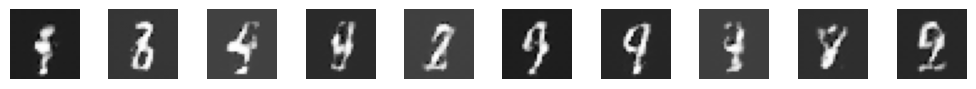

In [8]:
#GAN'lar tarafından üretilen görüntülerin karşılaştırılması
#üretilen görüntüleri görselleştirme
def plot_generated_images(generator, epoch, examples=10, dim=(1,10)):
    noise = np.random.normal(0, 1, (examples, z_dim)) #gürültü vektörleri
    gen_images = generator.predict(noise, verbose = 0) # üretilen görüntülerimiz
    gen_images = 0.5*gen_images + 0.5
    
    plt.figure(figsize=(10,1))
    for i in range(gen_images.shape[0]):
        plt.subplot(dim[0], dim[1], i+1) #alt grafikleri oluşturma 
        plt.imshow(gen_images[i, : ,:, 0], cmap="gray") #görüntüyü gri tonlama olarak göster
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()
    
#üretilen görüntüleri plot ettirme
plot_generated_images(generator, epochs)